In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data= pd.read_csv('Ordenes_productos_C1_M2.csv', sep=';',encoding='latin-1')

In [4]:
data.head(5)

,orden_id,order_item_id,producto_id,vendedor_id,fecha_envio_limite,precio,valor_flete,codigo_postal_vendedor,ciudad_vendedor,departamento_vendedor,nombre_categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_g_producto,longitud_cm_producto,altura_cm_producto,ancho_cm_producto
0,107500PO59A,A,PO59,VE5389,07/04/2018 18:12,271.86,30.72,52435,Mallama,Nariño,Productos ecoamigables,6,7,27,2486,17,11,14
1,37493PS22B,B,PS22,VE1558,20/10/2017 09:07,115.73,4.68,52203,Colon,Nariño,Carnicería,10,31,20,256,43,2,21
2,28050PK20B,B,PK20,VE9159,17/08/2017 08:15,432.99,82.70,66001,Pereira,Risaralda,Deportes,25,5,4,5270,9,27,29
3,52187PA10A,A,PA10,VE3159,23/09/2017 23:27,108.38,35.39,52435,Mallama,Nariño,Electrodomésticos,10,1,6,734,46,48,22
4,84639PR12A,A,PR12,VE5090,07/01/2018 11:50,51.50,11.10,73001,Ibague,Tolima,Frutas y verduras,23,16,35,884,45,26,18


In [4]:
# Revisar los tipos de data en el archivo
data.dtypes

orden_id                          object
order_item_id                     object
producto_id                       object
vendedor_id                       object
fecha_envio_limite                object
precio                           float64
valor_flete                      float64
codigo_postal_vendedor             int64
ciudad_vendedor                   object
departamento_vendedor             object
nombre_categoria_producto         object
longitud_nombre_producto           int64
longitud_descripcion_producto      int64
cantidad_fotos_producto            int64
peso_g_producto                    int64
longitud_cm_producto               int64
altura_cm_producto                 int64
ancho_cm_producto                  int64
dtype: object

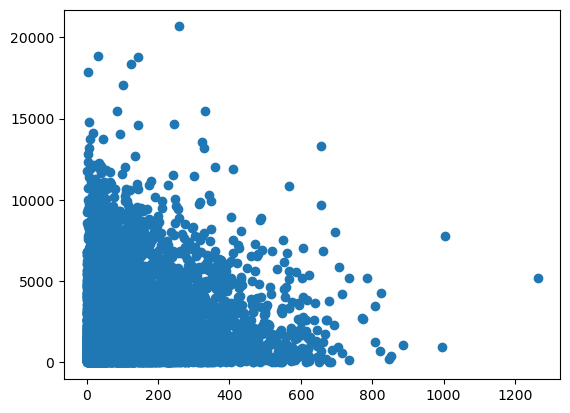

In [5]:
# Revisar la dispersión de los datos de precio y peso
plt.scatter(data['precio'], data['peso_g_producto']);

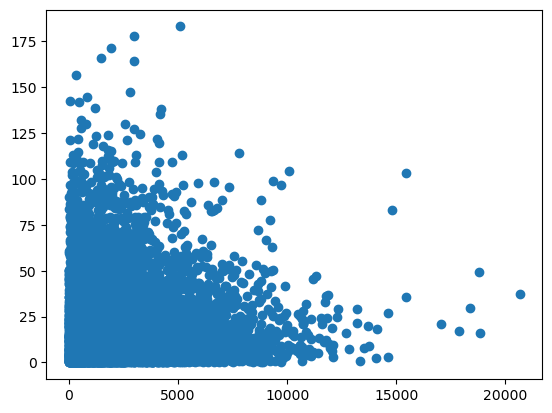

In [6]:
# Revisar la dispersión de los datos de precio y flete
plt.scatter(data['peso_g_producto'], data['valor_flete']);

In [7]:
# Calcular coeficiente de pearson para todos los datos numéricos
data[['precio','valor_flete','peso_g_producto']].corr(method='pearson')

,precio,valor_flete,peso_g_producto
precio,1.000000,0.004075,0.000687
valor_flete,0.004075,1.000000,-0.007394
peso_g_producto,0.000687,-0.007394,1.000000


In [7]:
#Crear medida del volumen y área del producto
data['area_cm2_producto']=data['longitud_cm_producto']*data['altura_cm_producto']

data['volumen_cm3_producto']=data['longitud_cm_producto']*data['altura_cm_producto']*data['ancho_cm_producto']
data.head()

,orden_id,order_item_id,producto_id,vendedor_id,fecha_envio_limite,precio,valor_flete,codigo_postal_vendedor,ciudad_vendedor,departamento_vendedor,nombre_categoria_producto,longitud_nombre_producto,longitud_descripcion_producto,cantidad_fotos_producto,peso_g_producto,longitud_cm_producto,altura_cm_producto,ancho_cm_producto,area_cm2_producto,volumen_cm3_producto
0,107500PO59A,A,PO59,VE5389,07/04/2018 18:12,271.86,30.72,52435,Mallama,Nariño,Productos ecoamigables,6,7,27,2486,17,11,14,187,2618
1,37493PS22B,B,PS22,VE1558,20/10/2017 09:07,115.73,4.68,52203,Colon,Nariño,Carnicería,10,31,20,256,43,2,21,86,1806
2,28050PK20B,B,PK20,VE9159,17/08/2017 08:15,432.99,82.70,66001,Pereira,Risaralda,Deportes,25,5,4,5270,9,27,29,243,7047
3,52187PA10A,A,PA10,VE3159,23/09/2017 23:27,108.38,35.39,52435,Mallama,Nariño,Electrodomésticos,10,1,6,734,46,48,22,2208,48576
4,84639PR12A,A,PR12,VE5090,07/01/2018 11:50,51.50,11.10,73001,Ibague,Tolima,Frutas y verduras,23,16,35,884,45,26,18,1170,21060


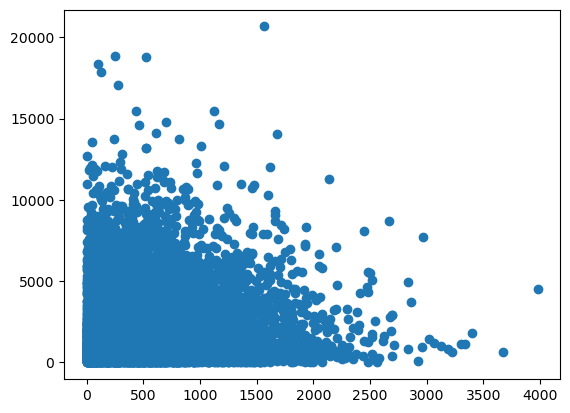

In [8]:
#graficar el área contra el peso
plt.scatter(data['area_cm2_producto'],data['peso_g_producto'])

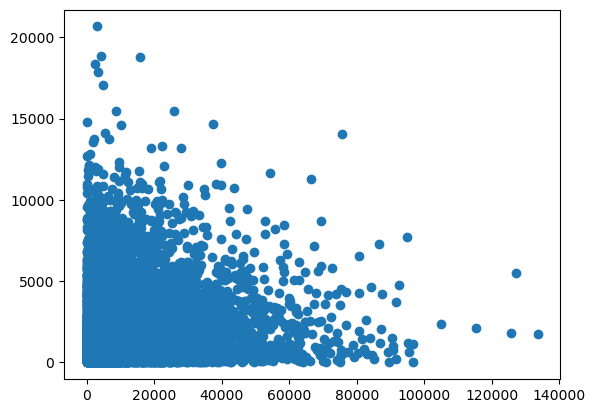

In [9]:
#graficar el volumen contra el peso
plt.scatter(data['volumen_cm3_producto'],data['peso_g_producto'])

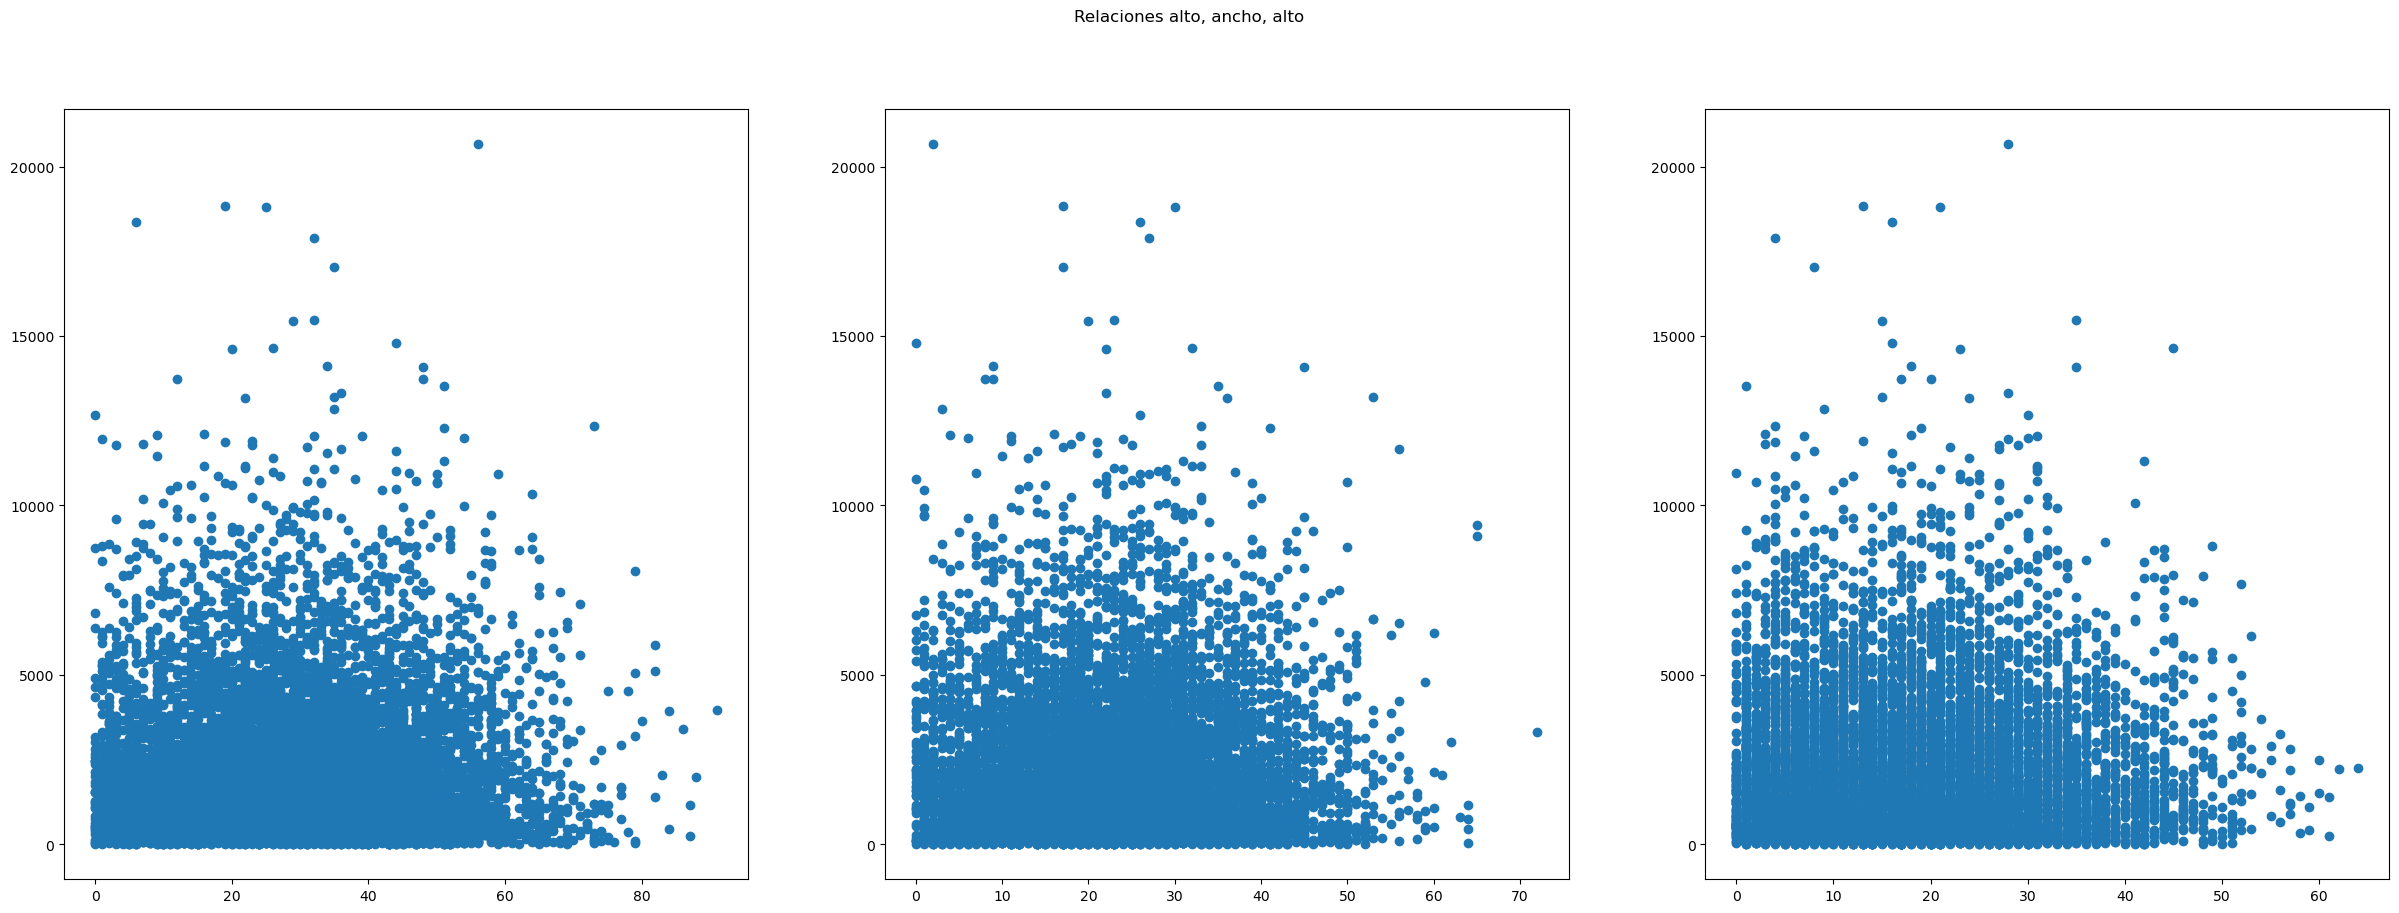

In [10]:
# graficar las demás relaciones alto, ancho, alto
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(30,10))
fig.suptitle('Relaciones alto, ancho, alto')
ax1.scatter(data['longitud_cm_producto'], data['peso_g_producto'])
ax2.scatter(data['ancho_cm_producto'], data['peso_g_producto'])
ax3.scatter(data['altura_cm_producto'], data['peso_g_producto'])

In [11]:
# matriz de correlaciones de spearman
corr=data[['longitud_cm_producto','altura_cm_producto',
      'ancho_cm_producto','peso_g_producto',
      'area_cm2_producto','volumen_cm3_producto','precio','valor_flete']].corr(method='spearman')
corr

,longitud_cm_producto,altura_cm_producto,ancho_cm_producto,peso_g_producto,area_cm2_producto,volumen_cm3_producto,precio,valor_flete
longitud_cm_producto,1.000000,0.002816,-0.004389,0.013190,0.584639,0.484020,-0.007994,0.001056
altura_cm_producto,0.002816,1.000000,0.011629,0.015161,0.753285,0.631474,-0.003369,-0.000340
ancho_cm_producto,-0.004389,0.011629,1.000000,0.014688,0.007347,0.471033,-0.013001,0.003442
peso_g_producto,0.013190,0.015161,0.014688,1.000000,0.022410,0.022648,-0.009197,-0.003148
area_cm2_producto,0.584639,0.753285,0.007347,0.022410,1.000000,0.838702,-0.006044,0.000411
volumen_cm3_producto,0.484020,0.631474,0.471033,0.022648,0.838702,1.000000,-0.012369,0.003331
precio,-0.007994,-0.003369,-0.013001,-0.009197,-0.006044,-0.012369,1.000000,0.010807
valor_flete,0.001056,-0.000340,0.003442,-0.003148,0.000411,0.003331,0.010807,1.000000


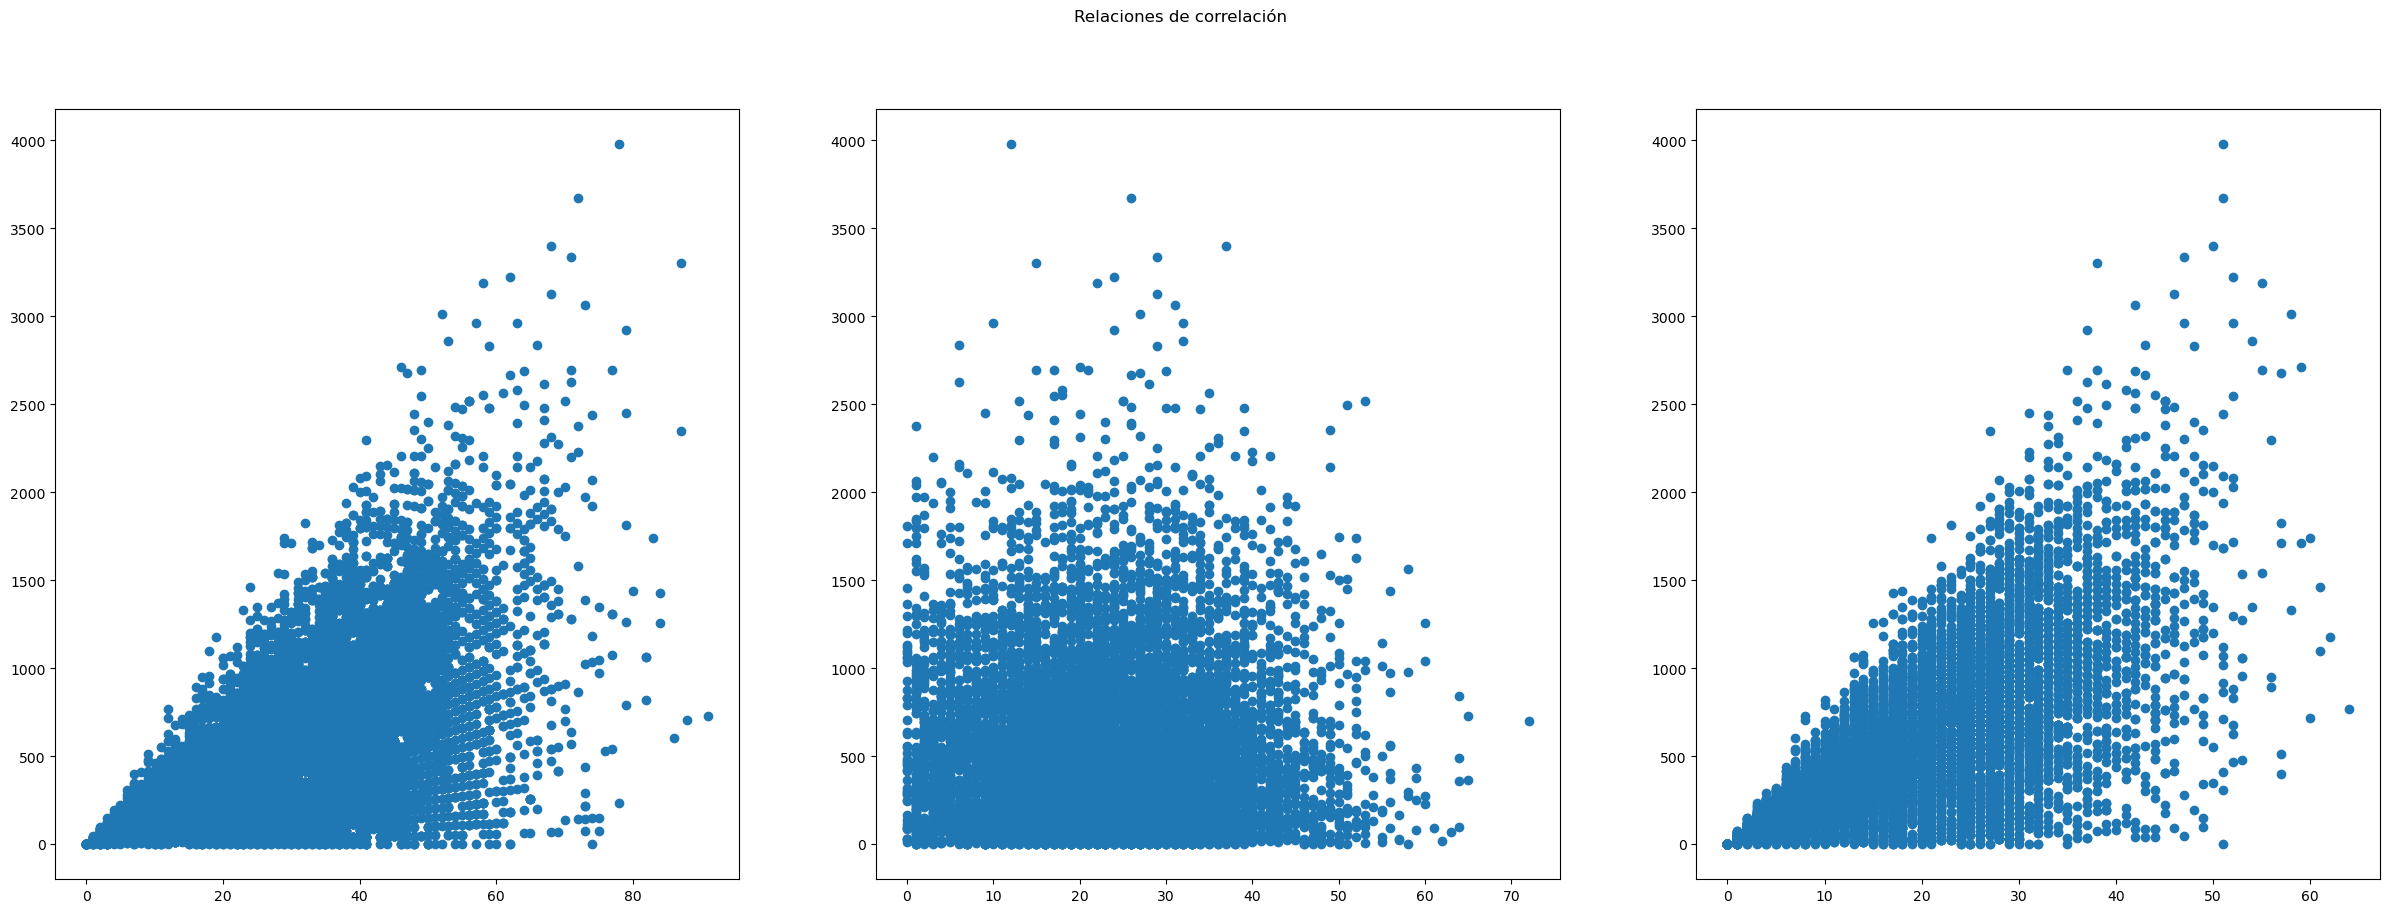

In [12]:
#Graficar las variables con correlación
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(30,10))
fig.suptitle('Relaciones de correlación')
ax1.scatter(data['longitud_cm_producto'], data['area_cm2_producto'])
ax2.scatter(data['ancho_cm_producto'], data['area_cm2_producto'])
ax3.scatter(data['altura_cm_producto'], data['area_cm2_producto'])

In [15]:
#Graficar las correlaciones
corr.style.background_gradient(cmap='coolwarm').format(precision=2)

,longitud_cm_producto,altura_cm_producto,ancho_cm_producto,peso_g_producto,area_cm2_producto,volumen_cm3_producto,precio,valor_flete
longitud_cm_producto,1.00,0.00,-0.00,0.01,0.58,0.48,-0.01,0.00
altura_cm_producto,0.00,1.00,0.01,0.02,0.75,0.63,-0.00,-0.00
ancho_cm_producto,-0.00,0.01,1.00,0.01,0.01,0.47,-0.01,0.00
peso_g_producto,0.01,0.02,0.01,1.00,0.02,0.02,-0.01,-0.00
area_cm2_producto,0.58,0.75,0.01,0.02,1.00,0.84,-0.01,0.00
volumen_cm3_producto,0.48,0.63,0.47,0.02,0.84,1.00,-0.01,0.00
precio,-0.01,-0.00,-0.01,-0.01,-0.01,-0.01,1.00,0.01
valor_flete,0.00,-0.00,0.00,-0.00,0.00,0.00,0.01,1.00
